Steam Top Sellers Analysis

This notebook analyzes three snapshots of Steam's top-selling games collected during 2026. The analysis examines what factors are associated with game performance, how the Steam market is changing in the short term, and where potential market opportunities may exist.


In [259]:
import pandas as pd 
import sqlite3 
import numpy as np
import seaborn as sns
import ast
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.colors import Normalize



df_05_17 = pd.read_csv(r'D:\Steam_top1000\Data\steam_top_sellers_2026-05-17.csv')
df_06_02 = pd.read_csv(r'D:\Steam_top1000\Data\steam_top_sellers_2026-06-02.csv')
df_07_02 = pd.read_csv(r'D:\Steam_top1000\Data\steam_top_sellers_2026-07-02.csv')


I decided to have the database delete and rebuild itself each time to insure my keys are being enforced correctly each run of this notebook.
I had built a function to create my tables and in that function I use if_exist='append' instead of if_exist='replace' as to make sure pandas cannot overwrite my keys.

In [260]:
#Asurring db is closed so the file can be deleted and remade 
if 'conn' in globals():
    conn.close()

#As mentioned above, deleting the database so 
if os.path.exists('steam_games.db'):
    os.remove('steam_games.db')

# Create a new database connection
conn = sqlite3.connect('steam_games.db')
#Creating the cursor
curs = conn.cursor()

# Turn on foreign key enforcement
#This will be needed to ensure the foreign keys I create are enforced properly when building the database
curs.execute("PRAGMA foreign_keys = ON")

For the next several lines I explored the three dataframes; checking the layout, viewing null counts, verifying dtypes and overall getting my thoughts for how this data needed to be cleaned.

In [261]:

df_05_17.head()

,rank,appId,title,url,releaseDate,priceText,finalPriceCents,discountPercent,reviewSummary,reviewPercent,...,marketPosition,opportunityType,pricingPosition,audienceSignal,monetizationSignal,competitiveSignal,intelligenceTags,riskFlags,insightSummary,recommendedAction
0,1,1962700,Subnautica 2,https://store.steampowered.com/app/1962700/Sub...,"May 14, 2026",$29.99,2999,0.0,Very Positive,94.0,...,Breakout leader,Benchmark competitor,Mid-market,Community / multiplayer audience,Paid upfront,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Subnautica 2 is a breakout leader, opportunity...","Use as a benchmark for capsule, pricing, tags,..."
1,2,2483190,Forza Horizon 6,https://store.steampowered.com/app/2483190/For...,"May 18, 2026",$69.99,6999,0.0,Very Positive,86.0,...,Standard competitor,Baseline market data,High-ticket,Community / multiplayer audience,Paid upfront,Comparable baseline,"['loved-by-players', 'social-retention-loop', ...",[],"Forza Horizon 6 is a standard competitor, oppo...",Use as baseline competitor data; enrich with r...
2,3,730,Counter-Strike 2,https://store.steampowered.com/app/730/Counter...,"Aug 21, 2012",Free,1499,NaN,Very Positive,86.0,...,Breakout leader,Benchmark competitor,Free-to-play,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Counter-Strike 2 is a breakout leader, opportu...","Use as a benchmark for capsule, pricing, tags,..."
3,4,2767030,Marvel Rivals,https://store.steampowered.com/app/2767030/Mar...,"Dec 5, 2024",Free,0,NaN,Mostly Positive,77.0,...,Breakout leader,Benchmark competitor,Free-to-play,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Marvel Rivals is a breakout leader, opportunit...","Use as a benchmark for capsule, pricing, tags,..."
4,5,2215200,LEGO® Batman™: Legacy of the Dark Knight,https://store.steampowered.com/app/2215200/LEG...,"May 22, 2026",$69.99,6999,0.0,NaN,NaN,...,Early momentum signal,Watchlist candidate,High-ticket,Community / multiplayer audience,Paid upfront,Comparable baseline,"['social-retention-loop', 'fresh-release']",['review-data-missing-or-not-yet-established'],LEGO® Batman™: Legacy of the Dark Knight is a ...,Monitor daily; early movement can reveal emerg...


In [262]:
df_05_17.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rank                  1000 non-null   int64  
 1   appId                 1000 non-null   int64  
 2   title                 1000 non-null   str    
 3   url                   1000 non-null   str    
 4   releaseDate           1000 non-null   str    
 5   priceText             999 non-null    str    
 6   finalPriceCents       1000 non-null   int64  
 7   discountPercent       900 non-null    float64
 8   reviewSummary         979 non-null    str    
 9   reviewPercent         979 non-null    float64
 10  reviewCount           979 non-null    float64
 11  platforms             1000 non-null   str    
 12  imageUrl              1000 non-null   str    
 13  scrapedAt             1000 non-null   str    
 14  currentPlayers        990 non-null    float64
 15  developer             501 non-nul

In [263]:
df_05_17.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [264]:
df_05_17.isnull().sum()

rank                      0
appId                     0
title                     0
url                       0
releaseDate               0
priceText                 1
finalPriceCents           0
discountPercent         100
reviewSummary            21
reviewPercent            21
reviewCount              21
platforms                 0
imageUrl                  0
scrapedAt                 0
currentPlayers           10
developer               499
publisher               501
genres                    0
categories                0
recommendationsTotal    546
metacriticScore         870
shortDescription        497
isFree                  497
type                    497
demandScore               0
qualityScore              0
commercialScore           0
momentumScore             0
opportunityScore          0
marketPosition            0
opportunityType           0
pricingPosition           0
audienceSignal            0
monetizationSignal        0
competitiveSignal         0
intelligenceTags    

In [265]:
df_06_02.head()

,rank,appId,title,url,releaseDate,priceText,finalPriceCents,discountPercent,reviewSummary,reviewPercent,...,marketPosition,opportunityType,pricingPosition,audienceSignal,monetizationSignal,competitiveSignal,intelligenceTags,riskFlags,insightSummary,recommendedAction
0,1,730,Counter-Strike 2,https://store.steampowered.com/app/730/Counter...,"Aug 21, 2012",Free,1499,NaN,Very Positive,86.0,...,Breakout leader,Benchmark competitor,Free-to-play,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Counter-Strike 2 is a breakout leader, opportu...","Use as a benchmark for capsule, pricing, tags,..."
1,2,2483190,Forza Horizon 6,https://store.steampowered.com/app/2483190/For...,"May 18, 2026",$69.99,6999,0.0,Very Positive,86.0,...,Breakout leader,Benchmark competitor,High-ticket,Community / multiplayer audience,Paid upfront,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Forza Horizon 6 is a breakout leader, opportun...","Use as a benchmark for capsule, pricing, tags,..."
2,3,359550,Tom Clancy's Rainbow Six Siege,https://store.steampowered.com/app/359550/Tom_...,"Dec 1, 2015",Free,999,NaN,Very Positive,82.0,...,Breakout leader,Benchmark competitor,Free-to-play,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],Tom Clancy's Rainbow Six Siege is a breakout l...,"Use as a benchmark for capsule, pricing, tags,..."
3,4,1675200,Steam Deck,https://store.steampowered.com/app/1675200/Ste...,"Jan 17, 2025",$789.00,39900,0.0,NaN,NaN,...,Non-game / accessory listing,Catalog monitoring,High-ticket,General Steam audience,Paid upfront,Comparable baseline,['non-game-hardware'],"['review-data-missing-or-not-yet-established',...","Steam Deck is a non-game / accessory listing, ...","Keep for catalog awareness, but exclude from g..."
4,5,2694490,Path of Exile 2,https://store.steampowered.com/app/2694490/Pat...,"Dec 6, 2024",$14.99,1499,50.0,Mostly Positive,76.0,...,Breakout leader,Benchmark competitor,Promotional discount,Community / multiplayer audience,Discount-driven sales,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Path of Exile 2 is a breakout leader, opportun...","Use as a benchmark for capsule, pricing, tags,..."


In [266]:
df_06_02.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rank                  1000 non-null   int64  
 1   appId                 1000 non-null   int64  
 2   title                 1000 non-null   str    
 3   url                   1000 non-null   str    
 4   releaseDate           999 non-null    str    
 5   priceText             998 non-null    str    
 6   finalPriceCents       1000 non-null   int64  
 7   discountPercent       885 non-null    float64
 8   reviewSummary         969 non-null    str    
 9   reviewPercent         969 non-null    float64
 10  reviewCount           969 non-null    float64
 11  platforms             1000 non-null   str    
 12  imageUrl              1000 non-null   str    
 13  scrapedAt             1000 non-null   str    
 14  currentPlayers        983 non-null    float64
 15  developer             397 non-nul

In [267]:
df_06_02.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [268]:
df_06_02.isnull().sum()

rank                      0
appId                     0
title                     0
url                       0
releaseDate               1
priceText                 2
finalPriceCents           0
discountPercent         115
reviewSummary            31
reviewPercent            31
reviewCount              31
platforms                 0
imageUrl                  0
scrapedAt                 0
currentPlayers           17
developer               603
publisher               606
genres                    0
categories                0
recommendationsTotal    659
metacriticScore         882
shortDescription        601
isFree                  600
type                    600
demandScore               0
qualityScore              0
commercialScore           0
momentumScore             0
opportunityScore          0
marketPosition            0
opportunityType           0
pricingPosition           0
audienceSignal            0
monetizationSignal        0
competitiveSignal         0
intelligenceTags    

In [269]:
df_07_02.head()

,rank,appId,title,url,releaseDate,priceText,finalPriceCents,discountPercent,reviewSummary,reviewPercent,...,marketPosition,opportunityType,pricingPosition,audienceSignal,monetizationSignal,competitiveSignal,intelligenceTags,riskFlags,insightSummary,recommendedAction
0,1,4165910,Steam Machine,https://store.steampowered.com/app/4165910/Ste...,"Jun 22, 2026","$1,049.00",104900,0.0,NaN,NaN,...,Non-game / accessory listing,Catalog monitoring,High-ticket,General Steam audience,Paid upfront,Comparablea baseline,"['fresh-release', 'non-game-hardware']","['review-data-missing-or-not-yet-established',...",Steam Machine is aa non-game / accessory listi...,"Keep for catalog awareness, but exclude from g..."
1,2,2767030,Marvel Rivals,https://store.steampowered.com/app/2767030/Mar...,"Dec 5, 2024",Free,0,NaN,Mostly Positive,77.0,...,Commercially aggressive,Pricing/monetization benchmark,Free-to-play,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['high-demand', 'loved-by-players', 'free-to-p...",[],"Marvel Rivals is a commercially aggressive, op...","Compare discount depth, price tier, and moneti..."
2,3,730,Counter-Strike 2,https://store.steampowered.com/app/730/Counter...,"Aug 21, 2012",Free,1499,NaN,Very Positive,86.0,...,Breakout leader,Benchmark competitor,Free-to-play,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Counter-Strike 2 is a breakout leader, opportu...","Use as a benchmark for capsule, pricing, tags,..."
3,4,4704690,MECCHA CHAMELEON,https://store.steampowered.com/app/4704690/MEC...,"Jun 9, 2026",$5.99,599,0.0,Very Positive,89.0,...,Breakout leader,Benchmark competitor,Budget,Community / multiplayer audience,Paid upfront,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"MECCHA CHAMELEON is a breakout leader, opportu...","Use as a benchmark for capsule, pricing, tags,..."
4,5,252490,Rust,https://store.steampowered.com/app/252490/Rust/,"Feb 8, 2018",$19.99,1999,50.0,Very Positive,86.0,...,Breakout leader,Benchmark competitor,Promotional discount,Community / multiplayer audience,Base game plus in-app purchases,Strong incumbent - study positioning and reten...,"['tier-1-opportunity', 'high-demand', 'loved-b...",[],"Rust is a breakout leader, opportunity score 9...","Use as a benchmark for capsule, pricing, tags,..."


In [270]:
df_07_02.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rank                  1000 non-null   int64  
 1   appId                 1000 non-null   int64  
 2   title                 1000 non-null   str    
 3   url                   1000 non-null   str    
 4   releaseDate           1000 non-null   str    
 5   priceText             997 non-null    str    
 6   finalPriceCents       1000 non-null   int64  
 7   discountPercent       905 non-null    float64
 8   reviewSummary         965 non-null    str    
 9   reviewPercent         965 non-null    float64
 10  reviewCount           965 non-null    float64
 11  platforms             1000 non-null   str    
 12  imageUrl              1000 non-null   str    
 13  scrapedAt             1000 non-null   str    
 14  currentPlayers        979 non-null    float64
 15  developer             530 non-nul

In [271]:
df_07_02.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [272]:
df_07_02.isnull().sum()

rank                      0
appId                     0
title                     0
url                       0
releaseDate               0
priceText                 3
finalPriceCents           0
discountPercent          95
reviewSummary            35
reviewPercent            35
reviewCount              35
platforms                 0
imageUrl                  0
scrapedAt                 0
currentPlayers           21
developer               470
publisher               474
genres                    0
categories                0
recommendationsTotal    523
metacriticScore         827
shortDescription        468
isFree                  468
type                    468
demandScore               0
qualityScore              0
commercialScore           0
momentumScore             0
opportunityScore          0
marketPosition            0
opportunityType           0
pricingPosition           0
audienceSignal            0
monetizationSignal        0
competitiveSignal         0
intelligenceTags    

With the data all coming from the Steam Market Intelligence AP, all three of the dataframes had the same columns so I decided to do my cleaning through a for loop so I could change each individual data frame to keep everything cohesive and allow for each to still be viewed as just one snapshot.
I created the combined dataframe to build for my lookup tables, I needed all three to be combined so when I assigned the IDs it would be consistent  across all three dataframes 

In [273]:
# Created a variable to hold the three dataframes for May, June, and July
df_05_to_07 = [(df_05_17, '2026-05-17'),(df_06_02, '2026-06-02'),(df_07_02, '2026-07-02')]

#Created to keep consistency  when creating lookup tables 
dfs_combined = pd.concat([df_05_17, df_06_02, df_07_02], ignore_index=True)



In [274]:
#While checking my release date nulls I found Vale Index replecement tether which is not a game so I added it to the list of titles to drop below
dfs_combined.loc[dfs_combined['releaseDate'].isna(),['title', 'releaseDate']]

,title,releaseDate
1733,Valve Index® Replacement Tether,NaN


In [275]:
# Checking nulls across all three dataframes
dfs_combined.isnull().sum()

rank                       0
appId                      0
title                      0
url                        0
releaseDate                1
priceText                  6
finalPriceCents            0
discountPercent          310
reviewSummary             87
reviewPercent             87
reviewCount               87
platforms                  0
imageUrl                   0
scrapedAt                  0
currentPlayers            48
developer               1572
publisher               1581
genres                     0
categories                 0
recommendationsTotal    1728
metacriticScore         2579
shortDescription        1566
isFree                  1565
type                    1565
demandScore                0
qualityScore               0
commercialScore            0
momentumScore              0
opportunityScore           0
marketPosition             0
opportunityType            0
pricingPosition            0
audienceSignal             0
monetizationSignal         0
competitiveSig

I had decided that after verrifying that each dataframe was structured the same way with the same columns that I would do my cleaning across each by utilizing a for loop to make the same changes efficiently

In [ ]:
#AI assistated comments 
# #With all three being structured the same, as mentioned above, I created a for loop so that each change will be pushed to each seperate dataframe
#Created a for loop to iterate through the list of dataframes and perform the following operations on each dataframe:
for df, snapshot_date in df_05_to_07:
    #Dropped columns that are unneeded, I do not plan to use their information in this analysis 
    df.drop(columns=['recommendationsTotal', 'metacriticScore', 'shortDescription', 'isFree', 'recommendedAction'], inplace=True)

     #The dataframes are being renamed to have a 'tags' column instead of 'categories' as the content of that column are labled as 'tags' in the Steam store
    #Renamed the 'appId' column to 'appID' to match the naming convention of the other columns in the dataframe
    df.rename(columns={'categories': 'tags'}, inplace=True)
    df.rename(columns={'appId' : 'appID'}, inplace=True)

    #The following entries were removed:
    # **Steam Machine** and **Steam Deck** — consoles offered by Valve.
    # **EA Play** — a subscription service providing access to EA games.
    # **Replacement Tether** — a replacement part for the Valve Index VR headset.
    # **Lossless Scaling** — software used for image upscaling.
    # **Aseprite** — software used for creating pixel art and animations.
    df.drop(df[df['title'].isin(['Steam Machine', 'Steam Deck', 'EA Play', 'Replacement Tether', 'Lossless Scaling', 'Aseprite'])].index, inplace=True)
    #Data contained a 'type' coulumn for things like DLC, Software, and Hardware. I only needed those labled as 'games' so I dropped the rest of the rows that were not labled as 'games'
    df.drop(df[df['type'] != 'game'].index, inplace=True)

    #Dropping the row for the Call of Duty launcher by the appID to insure that the other Call of Duty's are not droped as they are the actual games 
    df.drop(df[df['appID'] == 1938090].index, inplace=True) 

    #Updating the missing publisher manually due to it being the only one missing 
    #Puiblisher was originally Nuverse (2022–2025) but the current publisher for the game is Skystone Games as of 2025 
        #-- [Marvel Snap - Wikipedia](https://en.wikipedia.org/wiki/Marvel_Snap)
    df.loc[df['appID'] == 1997040, 'publisher'] = 'Skystone Games'

    #I found the release date for Rayman Legends Retold and updated the missing release date in the dataframe. The game is set to be released on October 1, 2026
    #-- [Rayman Legends Retold — Ubisoft](https://www.ubisoft.com/en-us/games/rayman-legends-retold)
    df.loc[df['appID'] == 4084710, 'releaseDate'] = 'Oct 1, 2026' 


    # Reset the DataFrame index because some rows were deleted during cleaning
    df.reset_index(drop=True, inplace=True)

    # Renumbered the rank column as non-games where removed 
    # Updated ranking reflects just the games 
    df['rank'] = range(1, len(df) + 1)

    #Changing the data type of the 'releaseDate' column to a datetime object for easier manipulation and analysis
    # The 'snapshotDate' column is being created to hold the date of the snapshot to allow for some nulls as some games may not have released as of the snapshot date but still be in the top 1000 list of games on Steam counting their pre order sales
    df['releaseDate'] = pd.to_datetime(df['releaseDate'],format='%b %d, %Y', errors='coerce')
    df['snapshotDate'] = pd.Timestamp(snapshot_date)

    #Creating a new column to show if a game has been releaseed as of the snapshot date. This will be a boolean value where True means the game has been released and False means it has not been released yet
    df['releasedYet'] = (df['releaseDate'] <= df['snapshotDate'])

    # Changing the data type of the scrapedAt column to datetime as I noticed the data was ISO 8601 format but stored as a string 
    #AI was used to determine what format the date time was in to change it from a str to the proper datetime: ISO 8601 international standard
    df['scrapedAt'] = pd.to_datetime(df['scrapedAt'], format='ISO8601')

    #The genres, tags and platforms shown in the data appear to be formated as list, due to this I imported ast and decided to change the current type, str, to list
    df['genres'] = df['genres'].apply(ast.literal_eval)
    df['tags'] = df['tags'].apply(ast.literal_eval)
    df['platforms'] = df['platforms'].apply(ast.literal_eval)




dfs_combined = pd.concat([df_05_17, df_06_02, df_07_02], ignore_index=True)

I had realized half way through making the lookup tables that they where all relatively the same code, all be it genre, tag, and platform. With that in mind I decided to turn the lookup table into a function. I had added and if statment to allow the explode argument for the tables built from list: genre, tag  and platform.
After making the lookup tables I mapped the IDs to their correct values and then created the bases for my sql tables

In [ ]:
def cr_lookup( df, colm, colmID, explode= False ):
    lookup = df[[colm]].copy()

    if explode:
        lookup= lookup.explode(colm)

    lookup = (lookup.dropna(subset=[colm]).drop_duplicates().sort_values(colm).reset_index(drop=True))
    lookup[colmID] = lookup.index + 1

    return lookup




dev_lookup = cr_lookup(dfs_combined,'developer', 'developerID')
publisher_lookup = cr_lookup(dfs_combined,'publisher', 'publisherID')
snapshot_lookup = cr_lookup(dfs_combined,'snapshotDate', 'snapshotID')
genre_lookup = cr_lookup(dfs_combined,'genres', 'genreID', explode=True)
tag_lookup = cr_lookup(dfs_combined,'tags', 'tagID', explode=True)
platform_lookup = cr_lookup(dfs_combined, 'platforms', 'platformID', explode=True)

for df, snapshot_date in df_05_to_07:
    # Mapped developer and publisher names to their respective IDs
        df['developerID'] = df['developer'].map(dev_lookup.set_index('developer')['developerID'])
        df['publisherID'] = df['publisher'].map(publisher_lookup.set_index('publisher')['publisherID'])
        df['snapshotID'] = df['snapshotDate'].map(snapshot_lookup.set_index('snapshotDate')['snapshotID'])

dfs_combined = pd.concat([df_05_17, df_06_02, df_07_02], ignore_index=True)

dfs_combined['gameSnapshotID'] = dfs_combined.index + 1
game = dfs_combined[['appID','title','url', 'releaseDate', 'imageUrl', 'developerID', 'publisherID']].drop_duplicates(subset='appID').copy()
gameSnapshot = dfs_combined[[ 'gameSnapshotID', 'appID', 'snapshotID', 'rank', 'priceText', 'finalPriceCents', 'discountPercent', 'reviewSummary', 'reviewPercent', 'reviewCount', 'currentPlayers', 'releasedYet']].copy()
snapshot = dfs_combined[['snapshotID', 'snapshotDate', 'scrapedAt']].drop_duplicates(subset='snapshotID').drop_duplicates(subset='snapshotID').copy()
score = dfs_combined[['gameSnapshotID', 'demandScore', 'qualityScore', 'commercialScore', 'momentumScore', 'opportunityScore']].copy()
intelligence = dfs_combined[['gameSnapshotID', 'marketPosition', 'opportunityType', 'pricingPosition', 'audienceSignal', 'monetizationSignal', 'competitiveSignal', 'intelligenceTags', 'riskFlags', 'insightSummary']].copy()

score['scoreID'] = score.index + 1
intelligence['intelID'] = intelligence.index + 1



Just like the lookup table I had realized that all three of my junction tables are created the exact same way so I decided to build a funciton to create the tables. On both the lookup table and junction table I had included the dataframe paramter to allow for possible newer snapshots
I created the junction tables to separate multiple values within a single field into individual records, allowing the database to properly represent many-to-many relationships between games and their genres, tags, and supported platforms.

In [278]:

def cr_junc(df, colmID, colm_ls, lookup, colmID_lookup):
    junction = (df[colmID + [colm_ls]].explode(colm_ls).drop_duplicates().dropna(subset=[colm_ls]))
    junction[colmID_lookup] = junction[colm_ls].map(lookup.set_index(colm_ls)[colmID_lookup])
    junction = junction[colmID+ [colmID_lookup]]

    return junction

genre_junction = cr_junc(dfs_combined, ['gameSnapshotID'], 'genres', genre_lookup, 'genreID')
tag_junction = cr_junc(dfs_combined, ['gameSnapshotID'],'tags', tag_lookup, 'tagID')
platform_junction = cr_junc(dfs_combined, ['gameSnapshotID'],'platforms', platform_lookup, 'platformID')





In [279]:
dfs_combined[['snapshotDate', 'snapshotID']].drop_duplicates().sort_values('snapshotDate')

,snapshotDate,snapshotID
0,2026-05-17,1
446,2026-06-02,2
809,2026-07-02,3


In [280]:
#Checking for all games missing developer or publisher information in the combined dataframe
dfs_combined.loc[dfs_combined['developer'].isnull() | dfs_combined['publisher'].isnull(), 'title']

# Changes and updates made to fix missing developer and publisher information in the combined dataframe above so no result is expected now

Series([], Name: title, dtype: str)

In [281]:
dfs_combined[dfs_combined['title'].str.contains('Marvel Snap', case=False, na=False)][['appID', 'title']]

,appID,title
1123,1997040,MARVEL SNAP


In [282]:
dfs_combined.loc[dfs_combined['reviewSummary'].isnull() | dfs_combined['reviewPercent'].isnull() | dfs_combined['reviewCount'].isnull() | dfs_combined['currentPlayers'].isnull(), ['title', 'reviewSummary', 'reviewPercent', 'reviewCount', 'currentPlayers', 'releaseDate', 'releasedYet', 'snapshotDate']]

,title,reviewSummary,reviewPercent,reviewCount,currentPlayers,releaseDate,releasedYet,snapshotDate
1,Forza Horizon 6,Very Positive,86.0,7494.0,NaN,2026-05-18,False,2026-05-17
4,LEGO® Batman™: Legacy of the Dark Knight,NaN,NaN,NaN,NaN,2026-05-22,False,2026-05-17
15,Hell Let Loose: Vietnam,NaN,NaN,NaN,NaN,2026-06-18,False,2026-05-17
50,007 First Light,NaN,NaN,NaN,NaN,2026-05-27,False,2026-05-17
134,Assassin's Creed Black Flag Resynced,NaN,NaN,NaN,NaN,2026-07-09,False,2026-05-17
337,Gothic 1 Remake,NaN,NaN,NaN,NaN,2026-06-05,False,2026-05-17
419,STAR WARS: Galactic Racer™,NaN,NaN,NaN,NaN,2026-10-06,False,2026-05-17
436,Avatar Legends: The Fighting Game,NaN,NaN,NaN,NaN,2026-07-02,False,2026-05-17
454,ACE COMBAT 8: WINGS OF THEVE,NaN,NaN,NaN,NaN,2026-10-01,False,2026-06-02
476,CONTROL Resonant,NaN,NaN,NaN,NaN,2026-09-24,False,2026-06-02


With the addition of the releasedYet and snapshotDate columns, we can see that the 31 missing values in reviewSummary, reviewPercent, reviewCount, and currentPlayers are due to games that had not yet been released as of the snapshot date. Therefore, these null values are valid and will be kept in the dataset. With the exception of Forza Horizon 6 likely due to reviews from players of the beta and the early access, for the ones that preordered the premium eddition of the game, the games had no information due to not being released. 

In [283]:
#Above i noticed that there was a null value in priceText, searching through the priceText column I found the appID and title, with that I looked on steam and realized that this is the launcher for all modern Call of Duty games
#As such I will be dropping this row as it is not a game 
dfs_combined.loc[dfs_combined['priceText'].isnull(), ['appID', 'title', 'priceText', 'releaseDate', 'releasedYet', 'snapshotDate']]

,appID,title,priceText,releaseDate,releasedYet,snapshotDate


In [284]:
dfs_combined['priceText']

0       $29.99
1       $69.99
2         Free
3         Free
4       $69.99
         ...  
1278      Free
1279     $4.99
1280     $6.99
1281    $13.59
1282     $7.99
Name: priceText, Length: 1283, dtype: str

In [285]:
#It appears that all values that have nulls in the discountPercent column are for games that are free to play, as such I will be keeping the NaN as no discount would apply to a free to play game
dfs_combined.loc[dfs_combined['discountPercent'].isnull(), ['appID', 'title', 'priceText', 'releaseDate', 'releasedYet', 'snapshotDate', 'discountPercent']]

,appID,title,priceText,releaseDate,releasedYet,snapshotDate,discountPercent
2,730,Counter-Strike 2,Free,2012-08-21,True,2026-05-17,NaN
3,2767030,Marvel Rivals,Free,2024-12-05,True,2026-05-17,NaN
7,1172470,Apex Legends™,Free,2020-11-04,True,2026-05-17,NaN
11,230410,Warframe,Free,2013-03-25,True,2026-05-17,NaN
16,2357570,Overwatch®,Free,2023-08-10,True,2026-05-17,NaN
...,...,...,...,...,...,...,...
1244,3052450,Morimens,Free,2024-08-01,True,2026-07-02,NaN
1248,2819520,Viking Rise,Free,2024-05-21,True,2026-07-02,NaN
1251,212500,The Lord of the Rings Online™,Free,2012-06-06,True,2026-07-02,NaN
1267,2379740,Wizardry Variants Daphne,Free,2025-03-05,True,2026-07-02,NaN


In [286]:
# I found that most of the games that where missing a discount percent had Free in the priceText
# With that I wanted to see the count of all the games missing a discountPercent 
dfs_combined['discountPercent'].isnull().sum()

np.int64(173)

In [ ]:
#Above generated 173 nulls as expected so I looked through priceText to find all games that had Free listed and the amount is exactly 173, meaning that all the nulls should be valid as a free game would not have a discount 
(dfs_combined['priceText'] == 'Free').sum()

np.int64(173)

In [288]:
dfs_combined.dtypes

rank                                int64
appID                               int64
title                                 str
url                                   str
releaseDate                datetime64[us]
priceText                             str
finalPriceCents                     int64
discountPercent                   float64
reviewSummary                         str
reviewPercent                     float64
reviewCount                       float64
platforms                          object
imageUrl                              str
scrapedAt             datetime64[us, UTC]
currentPlayers                    float64
developer                             str
publisher                             str
genres                             object
tags                               object
type                                  str
demandScore                         int64
qualityScore                        int64
commercialScore                     int64
momentumScore                     

Here I stored all of my SQL queries into unique variables in preparation to buid my SQL tables using a function and it helps keeps my SQL separate from my Python code making the database structure easier to read, maintain, and modify

In [ ]:
dev_sql = """CREATE TABLE IF NOT EXISTS Developer(
        developerID INTEGER PRIMARY KEY, 
        developer TEXT NOT NULL)"""

publisher_sql= """CREATE TABLE IF NOT EXISTS Publisher (
        publisherID INTEGER PRIMARY KEY, 
        publisher TEXT NOT NULL)"""

snapshot_sql = """CREATE TABLE IF NOT EXISTS Snapshot (
        snapshotID INTEGER PRIMARY KEY, 
        snapshotDate DATETIME NOT NULL, 
        scrapedAt DATETIME)"""

game_sql = """CREATE TABLE IF NOT EXISTS Game (
        appID INTEGER PRIMARY KEY,
        title TEXT NOT NULL,
        url TEXT,
        releaseDate DATETIME,
        imageUrl TEXT,
        developerID INTEGER,
        publisherID INTEGER,

        FOREIGN KEY (developerID)
            REFERENCES Developer(developerID),

        FOREIGN KEY (publisherID)
            REFERENCES Publisher(publisherID))"""

gameSnapshot_sql = """CREATE TABLE IF NOT EXISTS GameSnapshot (
        gameSnapshotID INTEGER PRIMARY KEY,
        appID INTEGER NOT NULL,
        snapshotID INTEGER NOT NULL,
        rank INTEGER,
        priceText TEXT,
        finalPriceCents INTEGER,
        discountPercent REAL,
        reviewSummary TEXT,
        reviewPercent REAL,
        reviewCount REAL,
        currentPlayers REAL,
        releasedYet INTEGER,

        FOREIGN KEY (appID)
            REFERENCES Game(appID),

        FOREIGN KEY (snapshotID)
            REFERENCES Snapshot(snapshotID))"""

score_sql = """CREATE TABLE IF NOT EXISTS Score (
        scoreID INTEGER PRIMARY KEY,
        gameSnapshotID INTEGER NOT NULL,
        demandScore INTEGER,
        qualityScore INTEGER,
        commercialScore INTEGER,
        momentumScore INTEGER,
        opportunityScore INTEGER,

        FOREIGN KEY (gameSnapshotID)
            REFERENCES GameSnapshot(gameSnapshotID))"""

intell_sql = """CREATE TABLE IF NOT EXISTS Intelligence (
        intelID INTEGER PRIMARY KEY,
        gameSnapshotID INTEGER NOT NULL,
        marketPosition TEXT,
        opportunityType TEXT,
        pricingPosition TEXT,
        audienceSignal TEXT,
        monetizationSignal TEXT,
        competitiveSignal TEXT,
        intelligenceTags TEXT,
        riskFlags TEXT,
        insightSummary TEXT,

        FOREIGN KEY (gameSnapshotID)
            REFERENCES GameSnapshot(gameSnapshotID))"""

genre_sql = """CREATE TABLE IF NOT EXISTS Genre (
        genreID INTEGER PRIMARY KEY,
        genres TEXT NOT NULL)"""

tag_sql =  """CREATE TABLE IF NOT EXISTS Tag (
        tagID INTEGER PRIMARY KEY,
        tags TEXT NOT NULL)"""


platform_sql =  """CREATE TABLE IF NOT EXISTS Platforms (
        platformID INTEGER PRIMARY KEY,
        platforms TEXT NOT NULL)"""

gameGenre_sql = """CREATE TABLE IF NOT EXISTS GameGenre (
        gameSnapshotID INTEGER NOT NULL,
        genreID INTEGER NOT NULL,

        PRIMARY KEY (gameSnapshotID, genreID),

        FOREIGN KEY (gameSnapshotID)
            REFERENCES GameSnapshot(gameSnapshotID),

        FOREIGN KEY (genreID)
            REFERENCES Genre(genreID))"""

gameTag_sql = """CREATE TABLE IF NOT EXISTS GameTag (
        gameSnapshotID INTEGER NOT NULL,
        tagID INTEGER NOT NULL,

        PRIMARY KEY (gameSnapshotID, tagID),

        FOREIGN KEY (gameSnapshotID)
            REFERENCES GameSnapshot(gameSnapshotID),

        FOREIGN KEY (tagID)
            REFERENCES Tag(tagID))"""

gamePlatform_sql = """CREATE TABLE IF NOT EXISTS GamePlatform (
        gameSnapshotID INTEGER NOT NULL,
        platformID INTEGER NOT NULL,

        PRIMARY KEY (gameSnapshotID, platformID),

        FOREIGN KEY (gameSnapshotID)
            REFERENCES GameSnapshot(gameSnapshotID),

        FOREIGN KEY (platformID)
            REFERENCES Platforms(platformID))"""


Small function creating the tables, again just to help simplfy and tidy our code, I chose to use append here 

In [290]:
def cr_tb(df,tb_name, tb_sql, conn):
    conn.execute(tb_sql)
    df.to_sql(tb_name, conn, if_exists='append', index=False)

In [291]:
cr_tb(dev_lookup, 'Developer', dev_sql, conn)
cr_tb(publisher_lookup,'Publisher', publisher_sql, conn )
cr_tb(snapshot, 'Snapshot', snapshot_sql, conn)
cr_tb(genre_lookup,'Genre', genre_sql, conn)
cr_tb(tag_lookup, 'Tag', tag_sql, conn)
cr_tb(platform_lookup,'Platforms', platform_sql, conn )
cr_tb(game, 'Game', game_sql, conn)
cr_tb(gameSnapshot, 'GameSnapshot', gameSnapshot_sql, conn)
cr_tb(score, 'Score', score_sql, conn)
cr_tb(intelligence, 'Intelligence', intell_sql, conn)
cr_tb(genre_junction, 'GameGenre', gameGenre_sql, conn)
cr_tb(tag_junction, 'GameTag', gameTag_sql, conn)
cr_tb(platform_junction, 'GamePlatform', gamePlatform_sql, conn)



In [292]:
pd.read_sql("""PRAGMA foreign_key_check;""", conn)

,table,rowid,parent,fkid


In [293]:
tables = pd.read_sql("""SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name; """, conn )['name'].tolist()

for table in tables:
    print(f"\n--- {table} ---")
    display(pd.read_sql(f'PRAGMA table_info({table});', conn))


--- Developer ---


,cid,name,type,notnull,dflt_value,pk
0,0,developerID,INTEGER,0,None,1
1,1,developer,TEXT,1,None,0



--- Game ---


,cid,name,type,notnull,dflt_value,pk
0,0,appID,INTEGER,0,None,1
1,1,title,TEXT,1,None,0
2,2,url,TEXT,0,None,0
3,3,releaseDate,DATETIME,0,None,0
4,4,imageUrl,TEXT,0,None,0
5,5,developerID,INTEGER,0,None,0
6,6,publisherID,INTEGER,0,None,0



--- GameGenre ---


...

,cid,name,type,notnull,dflt_value,pk
0,0,scoreID,INTEGER,0,None,1
1,1,gameSnapshotID,INTEGER,1,None,0
2,2,demandScore,INTEGER,0,None,0
3,3,qualityScore,INTEGER,0,None,0
4,4,commercialScore,INTEGER,0,None,0
5,5,momentumScore,INTEGER,0,None,0
6,6,opportunityScore,INTEGER,0,None,0



--- Snapshot ---


,cid,name,type,notnull,dflt_value,pk
0,0,snapshotID,INTEGER,0,None,1
1,1,snapshotDate,DATETIME,1,None,0
2,2,scrapedAt,DATETIME,0,None,0



--- Tag ---


,cid,name,type,notnull,dflt_value,pk
0,0,tagID,INTEGER,0,None,1
1,1,tags,TEXT,1,None,0


In [ ]:
curs.execute('SELECT finalPriceCents / 100.0 AS price, currentPlayers, reviewPercent, reviewCount FROM GameSnapshot ')

pr_plr_review = pd.DataFrame(curs.fetchall(),columns= ['price', 'currentPlayers', 'reviewPercent', 'reviewCount'])

pr_plr_review

,price,currentPlayers,reviewPercent,reviewCount
0,29.99,211939.0,94.0,31043.0
1,69.99,NaN,86.0,7494.0
2,14.99,625148.0,86.0,2538318.0
3,0.00,109600.0,77.0,280478.0
4,69.99,NaN,NaN,NaN
...,...,...,...,...
1278,0.00,2071.0,63.0,60021.0
1279,4.99,225.0,85.0,3302.0
1280,6.99,882.0,79.0,1960.0
1281,13.59,212.0,89.0,1256.0


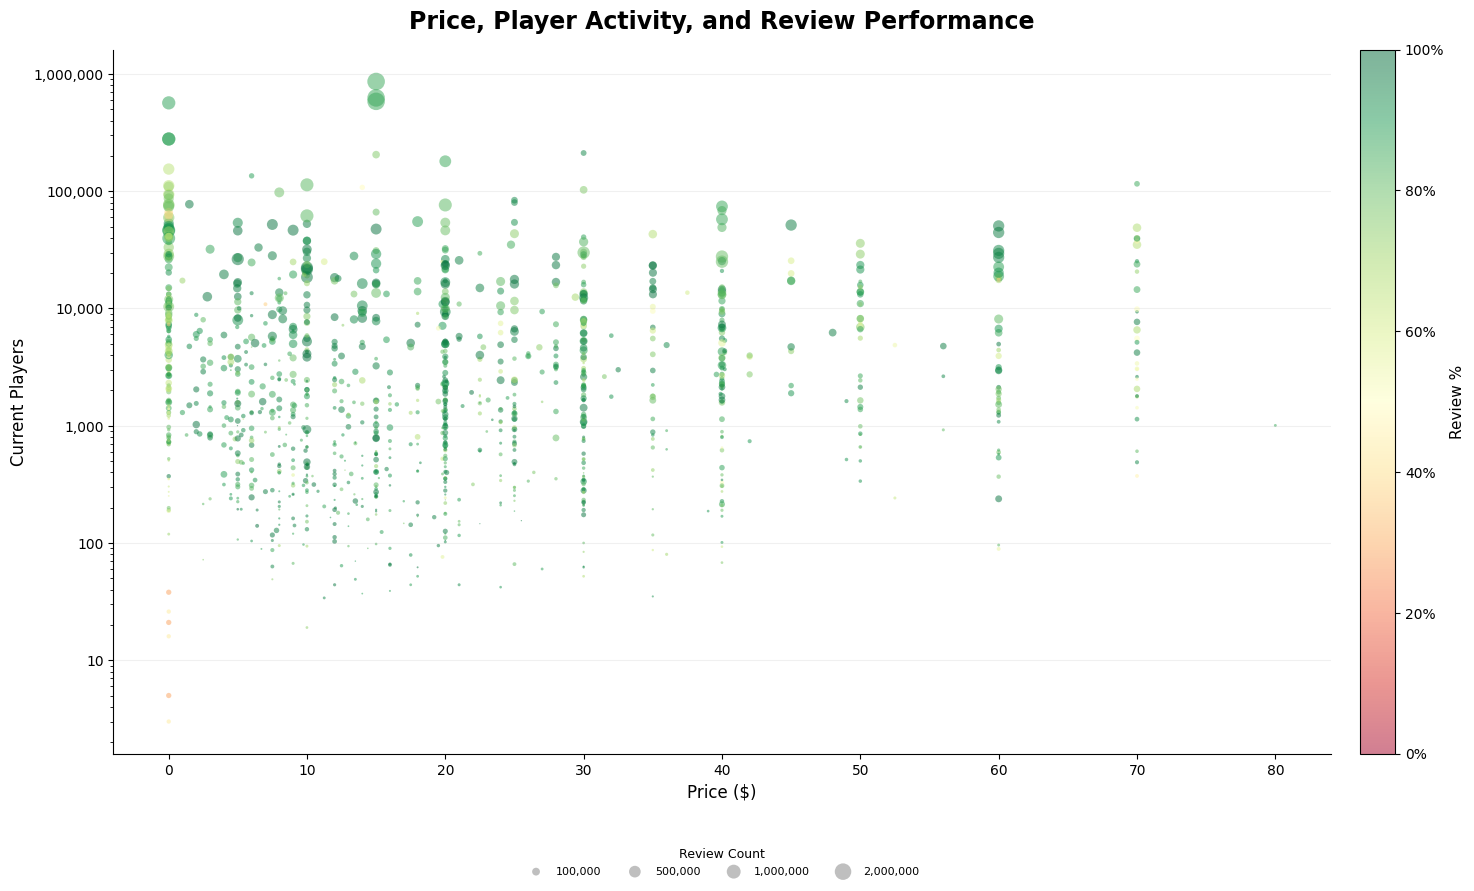

In [301]:

fig, ax = plt.subplots(figsize=(16, 9))

# -------------------------
# Color: Steam-style reviews
# -------------------------

norm = Normalize(vmin=0, vmax=100)

# Square-root scaling prevents huge review counts
# from completely dominating the plot
sizes = np.sqrt(pr_plr_review["reviewCount"]) / 10

scatter = ax.scatter(
    pr_plr_review["price"],
    pr_plr_review["currentPlayers"],
    c=pr_plr_review["reviewPercent"],
    cmap="RdYlGn",
    norm=norm,
    s=sizes,
    alpha=0.5,
    edgecolors="none"
)

# -------------------------
# Titles and labels
# -------------------------

ax.set_title(
    "Price, Player Activity, and Review Performance",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Price ($)", fontsize=12)
ax.set_ylabel("Current Players", fontsize=12)

# -------------------------
# Log Y-axis
# -------------------------

ax.set_yscale("log")

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

# -------------------------
# Grid
# -------------------------

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.8
)

ax.grid(axis="x", visible=False)

# -------------------------
# Spines
# -------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -------------------------
# Review % colorbar
# -------------------------

cbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Review %",
    fontsize=11
)

cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.set_ticklabels([
    "0%",
    "20%",
    "40%",
    "60%",
    "80%",
    "100%"
])

# -------------------------
# Review count legend
# -------------------------

review_count_values = [
    100_000,
    500_000,
    1_000_000,
    2_000_000
]

legend_handles = []

for value in review_count_values:

    size = np.sqrt(value) / 10

    legend_handles.append(
        ax.scatter(
            [],
            [],
            s=size,
            color="gray",
            alpha=0.5,
            edgecolors="none",
            label=f"{value:,}"
        )
    )

ax.legend(
    handles=legend_handles,
    title="Review Count",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False,
    fontsize=8,
    title_fontsize=9
)



plt.tight_layout()
plt.show()